In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np

from shapely.geometry import Point
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
gate_master_path = RAW_GATES / "border_crossings_master_raw.csv"

gate_master.to_csv(
    gate_master_path,
    index=False
)

print("Saved:", gate_master_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/raw/border_crossings/border_crossings_master_raw.csv


In [6]:
grid = gpd.read_file(
    INTERIM / "grid_1km_master.gpkg"
)

print("Grid cells:", len(grid))
print("CRS:", grid.crs)

Grid cells: 19001
CRS: EPSG:32635


In [7]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/turkiye-border-wellbeing")
RAW_GATES = ROOT / "data/raw/border_crossings"

RAW_GATES.mkdir(parents=True, exist_ok=True)

In [8]:
import pandas as pd

gate_master = pd.DataFrame({
    "gate_id": [
        "TR_BG_KAPIKULE",
        "TR_BG_HAMZABEYLI",
        "TR_BG_DEREKOY",
        "TR_GR_PAZARKULE",
        "TR_GR_IPSALA"
    ],
    "gate_name": [
        "Kapikule",
        "Hamzabeyli",
        "Derekoy",
        "Pazarkule",
        "Ipsala"
    ],
    "border_country": [
        "Bulgaria",
        "Bulgaria",
        "Bulgaria",
        "Greece",
        "Greece"
    ],
    "province": [
        "Edirne",
        "Edirne",
        "Kirklareli",
        "Edirne",
        "Edirne"
    ]
})

gate_master

,gate_id,gate_name,border_country,province
0,TR_BG_KAPIKULE,Kapikule,Bulgaria,Edirne
1,TR_BG_HAMZABEYLI,Hamzabeyli,Bulgaria,Edirne
2,TR_BG_DEREKOY,Derekoy,Bulgaria,Kirklareli
3,TR_GR_PAZARKULE,Pazarkule,Greece,Edirne
4,TR_GR_IPSALA,Ipsala,Greece,Edirne


In [9]:
gate_master_path = RAW_GATES / "border_crossings_master_raw.csv"

gate_master.to_csv(
    gate_master_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", gate_master_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/raw/border_crossings/border_crossings_master_raw.csv


In [10]:
pd.read_csv(gate_master_path)

,gate_id,gate_name,border_country,province
0,TR_BG_KAPIKULE,Kapikule,Bulgaria,Edirne
1,TR_BG_HAMZABEYLI,Hamzabeyli,Bulgaria,Edirne
2,TR_BG_DEREKOY,Derekoy,Bulgaria,Kirklareli
3,TR_GR_PAZARKULE,Pazarkule,Greece,Edirne
4,TR_GR_IPSALA,Ipsala,Greece,Edirne


In [11]:
gate_master = pd.DataFrame({
    "gate_id": [
        "TR_BG_KAPIKULE",
        "TR_BG_HAMZABEYLI",
        "TR_BG_DEREKOY",
        "TR_GR_PAZARKULE",
        "TR_GR_IPSALA"
    ],
    "gate_name": [
        "Kapikule",
        "Hamzabeyli",
        "Derekoy",
        "Pazarkule",
        "Ipsala"
    ],
    "border_country": [
        "Bulgaria",
        "Bulgaria",
        "Bulgaria",
        "Greece",
        "Greece"
    ],
    "province": [
        "Edirne",
        "Edirne",
        "Kirklareli",
        "Edirne",
        "Edirne"
    ],
    "latitude": [
        41.71475,
        41.95785,
        41.96764,
        41.65459,
        40.93114
    ],
    "longitude": [
        26.36280,
        26.61121,
        27.45913,
        26.49105,
        26.33239
    ],
    "coordinate_source": [
        "Apple Maps / border crossing station",
        "Apple Maps / border crossing station",
        "Apple Maps / border crossing station",
        "Apple Maps / border crossing station",
        "Apple Maps / border crossing station"
    ]
})

gate_master

,gate_id,gate_name,border_country,province,latitude,longitude,coordinate_source
0,TR_BG_KAPIKULE,Kapikule,Bulgaria,Edirne,41.71475,26.36280,Apple Maps / border crossing station
1,TR_BG_HAMZABEYLI,Hamzabeyli,Bulgaria,Edirne,41.95785,26.61121,Apple Maps / border crossing station
2,TR_BG_DEREKOY,Derekoy,Bulgaria,Kirklareli,41.96764,27.45913,Apple Maps / border crossing station
3,TR_GR_PAZARKULE,Pazarkule,Greece,Edirne,41.65459,26.49105,Apple Maps / border crossing station
4,TR_GR_IPSALA,Ipsala,Greece,Edirne,40.93114,26.33239,Apple Maps / border crossing station


In [12]:
gate_raw_path = RAW_GATES / "border_crossings_master_raw.csv"

gate_master.to_csv(
    gate_raw_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", gate_raw_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/raw/border_crossings/border_crossings_master_raw.csv


In [13]:
gates = gpd.GeoDataFrame(
    gate_master,
    geometry=gpd.points_from_xy(
        gate_master["longitude"],
        gate_master["latitude"]
    ),
    crs="EPSG:4326"
)

gates

,gate_id,gate_name,border_country,province,latitude,longitude,coordinate_source,geometry
0,TR_BG_KAPIKULE,Kapikule,Bulgaria,Edirne,41.71475,26.36280,Apple Maps / border crossing station,POINT (26.3628 41.71475)
1,TR_BG_HAMZABEYLI,Hamzabeyli,Bulgaria,Edirne,41.95785,26.61121,Apple Maps / border crossing station,POINT (26.61121 41.95785)
2,TR_BG_DEREKOY,Derekoy,Bulgaria,Kirklareli,41.96764,27.45913,Apple Maps / border crossing station,POINT (27.45913 41.96764)
3,TR_GR_PAZARKULE,Pazarkule,Greece,Edirne,41.65459,26.49105,Apple Maps / border crossing station,POINT (26.49105 41.65459)
4,TR_GR_IPSALA,Ipsala,Greece,Edirne,40.93114,26.33239,Apple Maps / border crossing station,POINT (26.33239 40.93114)


In [14]:
gates_utm = gates.to_crs("EPSG:32635")

print(gates_utm.crs)

EPSG:32635


In [15]:
gate_gpkg_path = RAW_GATES / "border_crossings_master_raw.gpkg"

gates.to_file(
    gate_gpkg_path,
    layer="border_crossings",
    driver="GPKG"
)

print("Saved:", gate_gpkg_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/raw/border_crossings/border_crossings_master_raw.gpkg


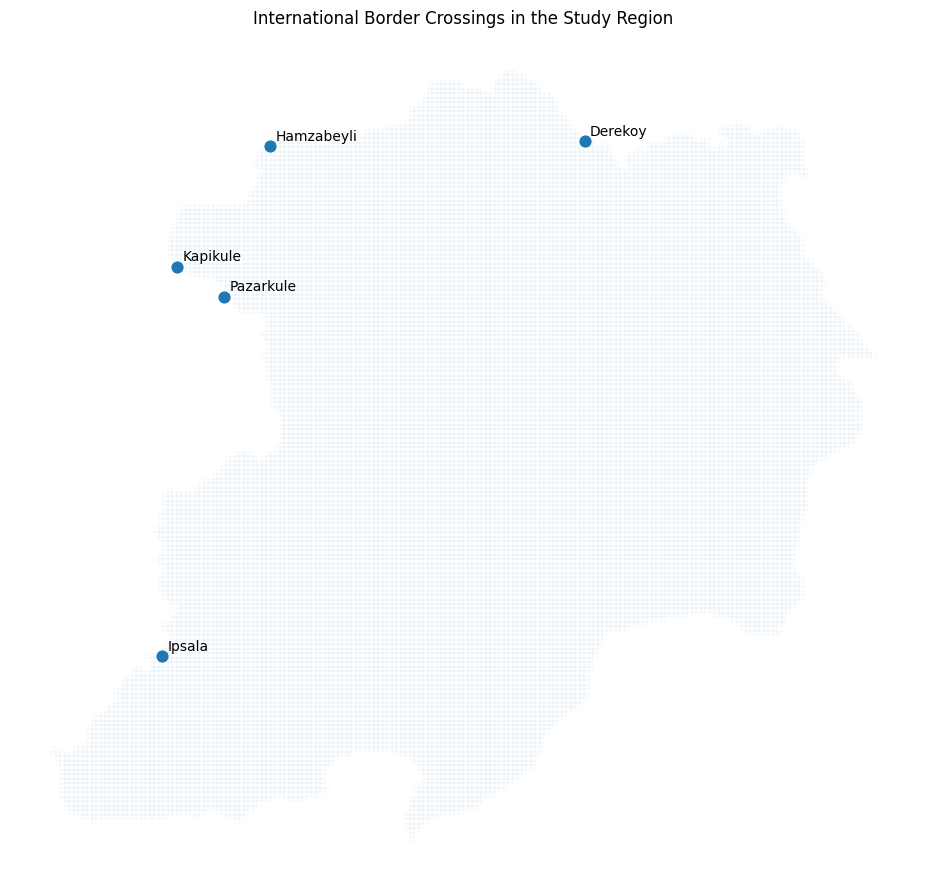

In [16]:
import matplotlib.pyplot as plt

grid = gpd.read_file(
    INTERIM / "grid_1km_master.gpkg"
)

fig, ax = plt.subplots(figsize=(10, 9))

grid.boundary.plot(
    ax=ax,
    linewidth=0.03
)

gates_utm.plot(
    ax=ax,
    markersize=60
)

for _, row in gates_utm.iterrows():
    ax.annotate(
        row["gate_name"],
        (row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points"
    )

ax.set_title("International Border Crossings in the Study Region")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [17]:
# Grid centroidlerini oluştur
grid_centroids = grid.copy()

grid_centroids["geometry"] = grid_centroids.geometry.centroid

# Sınır kapıları zaten gates_utm olarak EPSG:32635'te
print("Grid CRS:", grid_centroids.crs)
print("Gate CRS:", gates_utm.crs)

Grid CRS: EPSG:32635
Gate CRS: EPSG:32635


In [18]:
gate_names = gates_utm["gate_name"].tolist()

for _, gate in gates_utm.iterrows():
    col_name = f"dist_{gate['gate_name'].lower()}_km"

    grid_centroids[col_name] = (
        grid_centroids.geometry.distance(gate.geometry) / 1000
    )

print("Distance columns created.")

Distance columns created.


In [19]:
distance_cols = [
    col for col in grid_centroids.columns
    if col.startswith("dist_")
]

print(distance_cols)

['dist_kapikule_km', 'dist_hamzabeyli_km', 'dist_derekoy_km', 'dist_pazarkule_km', 'dist_ipsala_km']


In [20]:
grid_centroids["euclidean_distance_km"] = (
    grid_centroids[distance_cols].min(axis=1)
)

grid_centroids["nearest_gate_col"] = (
    grid_centroids[distance_cols].idxmin(axis=1)
)

In [21]:
grid_centroids["nearest_gate"] = (
    grid_centroids["nearest_gate_col"]
    .str.replace("dist_", "", regex=False)
    .str.replace("_km", "", regex=False)
)

In [22]:
gate_name_map = {
    "kapikule": "Kapikule",
    "hamzabeyli": "Hamzabeyli",
    "derekoy": "Derekoy",
    "pazarkule": "Pazarkule",
    "ipsala": "Ipsala"
}

grid_centroids["nearest_gate"] = (
    grid_centroids["nearest_gate"]
    .map(gate_name_map)
)

In [23]:
country_map = dict(
    zip(
        gates_utm["gate_name"],
        gates_utm["border_country"]
    )
)

grid_centroids["nearest_border_country"] = (
    grid_centroids["nearest_gate"]
    .map(country_map)
)

In [24]:
print(
    grid_centroids[
        [
            "grid_id",
            "nearest_gate",
            "nearest_border_country",
            "euclidean_distance_km"
        ]
    ].head(10)
)

   grid_id nearest_gate nearest_border_country  euclidean_distance_km
0  G000001       Ipsala                 Greece              32.659746
1  G000002       Ipsala                 Greece              32.000062
2  G000003       Ipsala                 Greece              33.322370
3  G000004       Ipsala                 Greece              32.614801
4  G000005       Ipsala                 Greece              31.922879
5  G000006       Ipsala                 Greece              38.859131
6  G000007       Ipsala                 Greece              38.044408
7  G000008       Ipsala                 Greece              37.238715
8  G000009       Ipsala                 Greece              36.442652
9  G000010       Ipsala                 Greece              35.656862


In [25]:
print(
    grid_centroids["nearest_gate"]
    .value_counts()
)

print()

print(
    grid_centroids["nearest_border_country"]
    .value_counts()
)

print()

print(
    grid_centroids["euclidean_distance_km"]
    .describe()
)

nearest_gate
Derekoy       8333
Ipsala        6518
Pazarkule     2945
Hamzabeyli    1032
Kapikule       173
Name: count, dtype: int64

nearest_border_country
Bulgaria    9538
Greece      9463
Name: count, dtype: int64

count    19001.000000
mean        48.146813
std         25.619933
min          0.341199
25%         28.222583
50%         43.796968
75%         67.705819
max        118.073222
Name: euclidean_distance_km, dtype: float64


In [26]:
access_csv = (
    INTERIM /
    "grid_border_accessibility_euclidean.csv"
)

grid_centroids.drop(
    columns="geometry"
).to_csv(
    access_csv,
    index=False
)

print("Saved:", access_csv)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/grid_border_accessibility_euclidean.csv


In [27]:
access_gpkg = (
    INTERIM /
    "grid_border_accessibility_euclidean.gpkg"
)

grid_centroids.to_file(
    access_gpkg,
    layer="grid_accessibility",
    driver="GPKG"
)

print("Saved:", access_gpkg)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/grid_border_accessibility_euclidean.gpkg


In [28]:
import json

access_metadata = {
    "measure": "Euclidean distance from each 1 km grid centroid to the nearest international border crossing",
    "distance_unit": "kilometres",
    "crs_used_for_distance": "EPSG:32635",
    "border_crossings": [
        "Kapikule",
        "Hamzabeyli",
        "Derekoy",
        "Pazarkule",
        "Ipsala"
    ],
    "main_grid_count": int(len(grid_centroids)),
    "note": "Euclidean distance is a baseline accessibility measure. Road-network accessibility will be constructed separately."
}

metadata_path = (
    INTERIM /
    "border_accessibility_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        access_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Saved:", metadata_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/border_accessibility_metadata.json
